In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow import keras
from keras.optimizers import Adam
from keras import Sequential
from keras.layers import Dense, Dropout
from keras import regularizers

In [5]:
x, y = make_moons(n_samples=100, noise=0.25, random_state = 2)

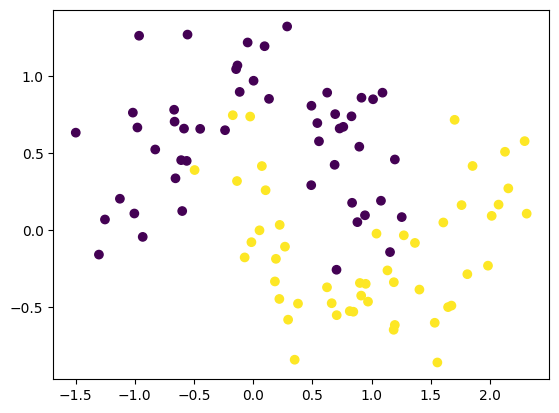

In [7]:
plt.scatter(x = x[:,0], y = x[:,1], c=y)

In [9]:
model = Sequential()

model.add(Dense(128, activation = 'relu', input_dim=2))
model.add(Dense(128, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
adam = Adam(learning_rate=0.01)
model.compile(loss = 'binary_crossentropy', optimizer=adam, metrics=['accuracy'])
history1 = model.fit(x, y, validation_split=0.2, epochs=2000, verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

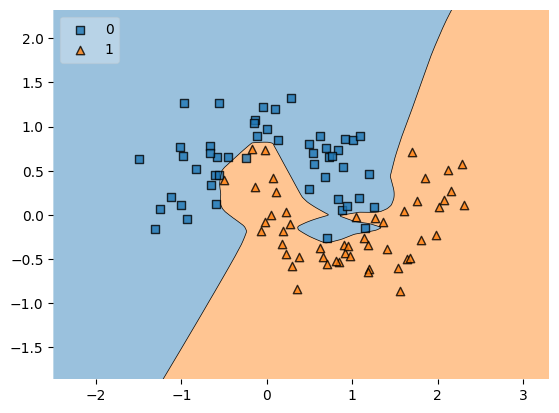

In [12]:
plot_decision_regions(x, y, clf = model, legend=2)

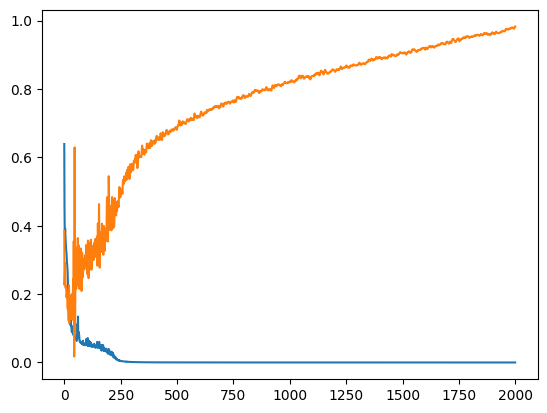

In [13]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

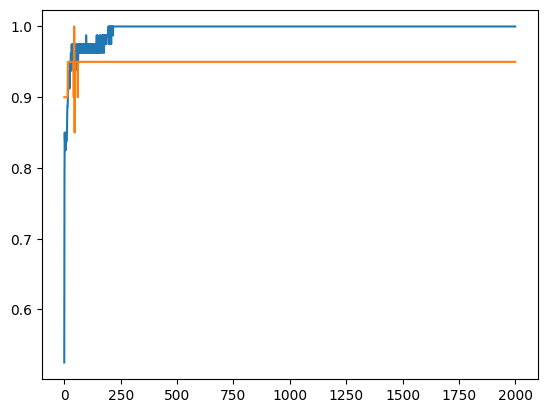

In [14]:
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])

In [16]:
model2 = Sequential()

model2.add(Dense(128, activation = 'relu', input_dim=2, kernel_regularizer=regularizers.l2(0.03)))
model2.add(Dense(128, activation = 'relu', kernel_regularizer=regularizers.l2(0.03)))
model2.add(Dense(1, activation = 'sigmoid'))

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
adam = Adam(learning_rate=0.01)
model2.compile(loss = 'binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(x, y, validation_split=0.2, epochs=2000)

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - accuracy: 0.3492 - loss: 4.3098 - val_accuracy: 0.8500 - val_loss: 2.7262
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7945 - loss: 2.4979 - val_accuracy: 0.9000 - val_loss: 1.5399
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7688 - loss: 1.4421 - val_accuracy: 0.9000 - val_loss: 0.8900
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8266 - loss: 0.8954 - val_accuracy: 0.9000 - val_loss: 0.6037
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7891 - loss: 0.7051 - val_accuracy: 0.9000 - val_loss: 0.5129
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7789 - loss: 0.6471 - val_accuracy: 0.9000 - val_loss: 0.5322
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8391 - loss: 0.6978 - val_accuracy: 0.9000 - val_loss: 0.6471
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7812 - loss: 0.7224 - val_accuracy: 0.9000 - 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

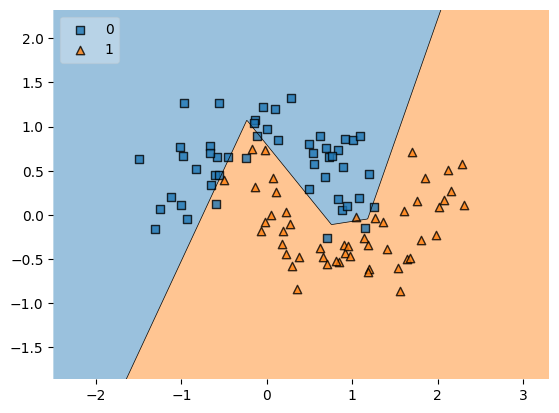

In [18]:
plot_decision_regions(x, y, clf=model2, legend=2)

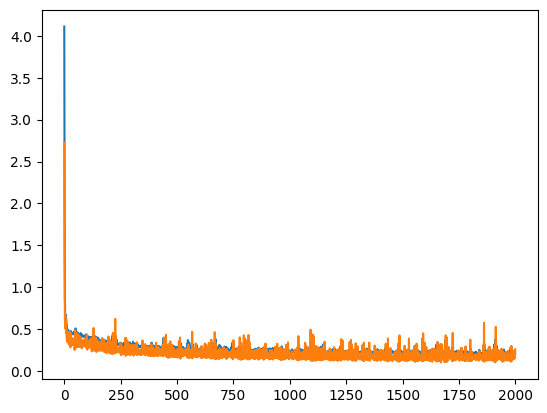

In [19]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

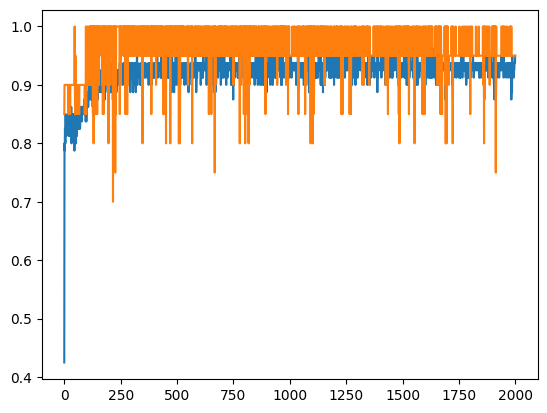

In [20]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])